---
tags: [algorithm, optimization, oracle-based]
---

# Solving the Channel Assignment Problem with Grover Adaptive Search 

This tutorial demonstrates how to solve the **Channel Assignment Problem (CAP)**
using the Grover Adaptive Search (GAS) algorithm with Qamomile.

This tutorial follow the paper
>Y. Sano, M. Norimoto and N. Ishikawa, IEEE Transactions on Quantum Engineering, vol. 4, pp. 1-12 (2023).

The original Grover Adaptive Search Method for Constrained Polynomial Binary Optimization comes from the following paper 
> Gilliam, Austin, et al. Quantum, 5, p428 (2021) https://doi.org/10.22331/q-2021-04-08-428.

In this tutorial, we will see:
0. What is the CAP and why GAS is adapted to solve it.
1. How to formulate the CAP with [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html).
2. How to create an instance using the data from the article.
3. How to use the `GASConverter` to build the Grover Adaptive Search circuit.
4. And how to run the circuit inside a classical adaptive search layer. Sample the circuit and keep the best solutions until a stopping criterion is reached.

# The Channel Assignment Problem

We are given $N_{AP}$ Access Points and $N_{CH}$ Channels, and assume $N_{CH} < N_{AP}$.
The goal is to assign a channel to each AP such that the network total (Shannon) capacity is maximized.

We call $U_i$ the set of Users Terminals (UT) that connect to a given Access Point $i$.
The received signal power can be computed as the product of the the AP power $P$ and the sum of the distance of each terminal to the AP $d_{iu}^{-\alpha}$ (where $\alpha$ is an attenuation coefficient).

Maximizing the capacity is mathematically equivalent to minimizing the interferences. An interference appears when two APs are connected to the same channel and the degree of interference is proportional to the received signal power.

<div align="center">

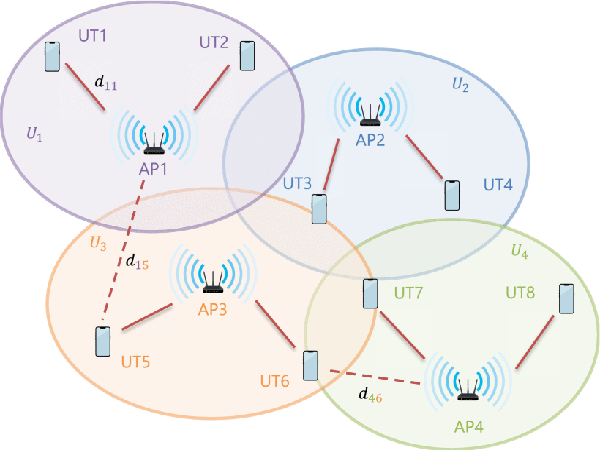

</div>

## QUBO encoding

For the QUBO encoding, we use a one-hot encoding.

Let's name $x_{ic} = \begin{cases} 1 \text{ if the } i \text{th AP uses the channel }c \\ 0 \text{ otherwise}\end{cases}$ 

$[x_{i1}, \ldots, x_{iN_{CH}}]$ is a one-hot vector, i.e. only one entry is one and the other are zero. 

For every two APs ($c$,$l$) that connect on the same channel $i$, we have the interferences:
\begin{equation*}
    \sum_{c=1}^{N_{CH}} \sum_{k=1}^{N_{AP}} \sum_{l=1}^{N_{CH}} \big( \sum_{u \in U_i} P d_{iu}^{-\alpha} \big) \delta_{cl} (1 - \delta_{ik}) x_{ic} x_{kl}
\end{equation*}

And optimizing the capacity is equivalent to

\begin{align}
    &\min_x \sum_{i=1}^{N_{AP}-1} \sum_{c=1}^{N_{CH}} \sum_{k=i+1}^{N_{AP}} \sum_{l=1}^{N_{CH}} D_{ik} \delta_{cl} (1 - \delta_{ik}) x_{ic} x_{kl} \\
    & \text{ under constraint } \sum_{c=1}^{N_{CH}} (x_{ic}) = 1, \forall i\in \lbrace 1, \ldots, N_{AP}\rbrace \text{ (each APs must use a single channel)}
\end{align}
where the $D_{ik}$ are scalar constant deduced from the capactity formula for pairwise interferences (see the paper for details).

# Modeling with JIJ Modeling

In [1]:
import jijmodeling as jm

@jm.Problem.define("Channel Assignment", sense=jm.ProblemSense.MINIMIZE)
def channel_assignment(problem: jm.DecoratedProblem):

    N_CH = problem.Length("N_CH")
    N_AP = problem.Length("N_AP")

    D = problem.Float("D", shape=(N_AP, N_AP),
                      description="Scalar constants for pairwise interferences between APs")

    x = problem.BinaryVar(
        shape=(N_AP, N_CH),
        description=r"$x_{i,c}$ is 1 if the AP $i$th uses channel $c$, 0 otherwise",
    )

    problem += jm.sum(
        D[i, k] * x[i, c] * x[k, c]
        for i in N_AP
        for k in N_AP
        if k > i
        for c in N_CH
    )

    problem += problem.Constraint(
        "APConstraint",
        (jm.sum(x[i, c] for c in N_CH) == 1 for i in N_AP),
        description="Each AP must use exactly one channel"
    )

channel_assignment

Problem(name="Channel Assignment", sense=MINIMIZE, objective=sum(N_AP.flat_map(lambda (i: natural): N_AP.map(lambda (k: natural): (i, k))).filter(lambda (i, k): k > i).flat_map(lambda ((i, k): Tuple[natural, natural]): N_CH.map(lambda (c: natural): (i, k, c))).map(lambda ((i, k, c): Tuple[natural, natural, natural]): D[i, k] * x[i, c] * x[k, c])), constraints={APConstraint: [Constraint(name="APConstraint", , lambda i: sum(N_CH.map(lambda (c: natural): x[i, c])) == 1, domain=set(N_AP), description="Each AP must use exactly one channel"),],})

# Instance (from the paper)

In [2]:
import numpy as np
from IPython.display import display

N_CH = 3
N_AP = 4
N_U = 8

#which UT is connected to which AP
connections = {
    0: [0,1],
    1: [2,3],
    2: [4,5],
    3: [6,7],
}

#dimension (N_AP, N_U)
d = np.array([
    [1, 1, 2, 4, 3, 5, 5, 8],
    [5, 4, 1, 1, 5, 4, 2, 4],
    [6, 5, 2, 5, 1, 1, 4, 6],
    [10, 8, 5, 2, 5, 3, 1, 1],
])

upper_idx = np.triu_indices(N_AP, k=1)
C = np.zeros((N_AP, N_AP), dtype=float)

for i, k in zip(*upper_idx):
    C[i, k] = (
        -np.log2(1 + np.sum(1 / d[i, connections[i]]) / np.sum(1 / d[i, connections[k]]))
        - np.log2(1 + np.sum(1 / d[k, connections[k]]) / np.sum(1 / d[k, connections[i]]))
    )

C_min = np.min(C[upper_idx])
epsilon = 0.01

D = np.zeros_like(C)
D[upper_idx] = C[upper_idx] - C_min + epsilon
D = np.round(D, decimals=3)
D

array([[0.   , 1.835, 1.216, 0.01 ],
       [0.   , 0.   , 1.762, 2.333],
       [0.   , 0.   , 0.   , 1.371],
       [0.   , 0.   , 0.   , 0.   ]])

In [3]:
instance_data = {
    "N_CH": N_CH,
    "N_AP": N_AP,
    "D": D.tolist(),
}
instance = channel_assignment.eval(instance_data)

In [6]:
from qamomile.optimization.gas import GASConverter
from qamomile.qiskit import QiskitTranspiler

converter = GASConverter(instance)
transpiler = QiskitTranspiler()

In [7]:
converter.binary_model.quad

{(0, 1): 2.0,
 (0, 2): 2.0,
 (0, 3): 1.835,
 (0, 6): 1.216,
 (0, 9): 0.01,
 (1, 2): 2.0,
 (1, 4): 1.835,
 (1, 7): 1.216,
 (1, 10): 0.01,
 (2, 5): 1.835,
 (2, 8): 1.216,
 (2, 11): 0.01,
 (3, 4): 2.0,
 (3, 5): 2.0,
 (3, 6): 1.762,
 (3, 9): 2.333,
 (4, 5): 2.0,
 (4, 7): 1.762,
 (4, 10): 2.333,
 (5, 8): 1.762,
 (5, 11): 2.333,
 (6, 7): 2.0,
 (6, 8): 2.0,
 (6, 9): 1.371,
 (7, 8): 2.0,
 (7, 10): 1.371,
 (8, 11): 1.371,
 (9, 10): 2.0,
 (9, 11): 2.0,
 (10, 11): 2.0}

In [8]:
effective_model = converter.approximate_real_valued_model(converter.binary_model, quantization_parameter=8)
effective_model.quad

{(0, 1): 64.0,
 (0, 2): 64.0,
 (0, 3): 59.0,
 (0, 6): 39.0,
 (1, 2): 64.0,
 (1, 4): 59.0,
 (1, 7): 39.0,
 (2, 5): 59.0,
 (2, 8): 39.0,
 (3, 4): 64.0,
 (3, 5): 64.0,
 (3, 6): 56.0,
 (3, 9): 75.0,
 (4, 5): 64.0,
 (4, 7): 56.0,
 (4, 10): 75.0,
 (5, 8): 56.0,
 (5, 11): 75.0,
 (6, 7): 64.0,
 (6, 8): 64.0,
 (6, 9): 44.0,
 (7, 8): 64.0,
 (7, 10): 44.0,
 (8, 11): 44.0,
 (9, 10): 64.0,
 (9, 11): 64.0,
 (10, 11): 64.0}

In [9]:
converter._required_output_bits(effective_model)

12

In [10]:
converter._required_output_bits(converter.binary_model)

7

In [59]:
from typing import Any
import numpy as np
import random
import ommx
from qiskit_aer import AerSimulator

def grover_adaptive_search(
    converter: Any,
    transpiler: Any,
    lamb: float,
    max_no_improvement: int = 5,
    seed: int = 900
):

    ##########################################################
    #                   Initialization                       #
    ##########################################################

    np.random.seed(seed)
    random.seed(seed)

    n = converter.binary_model.num_bits
    k = 1 #Control the upper bound of the number of Grover iterations sampled at each step
    
    indx = np.random.randint(0, N_CH, size=N_AP)
    x = np.zeros(N_AP * N_CH, dtype=int)
    x[ [indx[i] + i*N_CH for i in range(N_AP)] ]= 1

    y = converter.instance.evaluate({i: x_i for i, x_i in enumerate(x)}).objective

    current_iter = 0
    no_improvement_count = 0

    print("[GAS] Initialization")
    print(f"[GAS] n={n}, lambda={lamb}")
    print(f"[GAS] Start state: x={x}, y={y}, k={k}")

    executor = transpiler.executor(backend=AerSimulator(seed_simulator=seed,max_parallel_threads=None))

    ############################################################
    #                     Main Loop                            #
    ############################################################

    while no_improvement_count < max_no_improvement:
        
        # Sample t uniformly in {0, ..., ceil(k)-1}; avoid empty range when k == 1
        num_iterations = random.randrange(max(1, int(np.ceil(k))))
        print(
            f"\n[GAS] Iteration {current_iter + 1} | current y={y}, k={k:.6f}, "
            f"Grover iters={num_iterations}"
        )

        ####################################################
        #       Call to the Quantum Grover Circuit         #
        ####################################################

        exec = converter.transpile(transpiler,
                                y=y,
                                num_iterations=num_iterations,
                                approximate_real_coefficients=False, 
                                # quantization_parameter=8 #Or choose a quantization parameter
                                )

        #We run the circuit several time since NISQ hardware are noisy
        job = exec.sample(executor, shots=256)
        result = job.result()
        sample_set = converter.decode(result)

        best_sample = sample_set.best_feasible
        if best_sample is None:
            old_k = k
            k = lamb * k
            no_improvement_count += 1
            print("[GAS] No feasible sample found -> keeping current solution")
            print(f"[GAS] Scaling k: {old_k:.6f} -> {k:.6f}")
            current_iter += 1
            continue

        x_vals = best_sample.extract_decision_variables("x")
        candidate_x = [int(round(x_vals.get(i, x_vals.get((i,), 0.0)))) for i in range(n)]
        candidate_y = float(best_sample.objective)
        candidate_eval = converter.instance.evaluate({i: bit for i, bit in enumerate(candidate_x)})

        print(f"[GAS] Candidate x: {candidate_x}")

        if candidate_eval.feasible and candidate_y < y:
            print(f"[GAS] Candidate objective: y={candidate_y}")
            print("[GAS] Improvement found -> accepting candidate and resetting k to 1")
            x = candidate_x
            y = candidate_y
            k = 1
            no_improvement_count = 0
        else:
            old_k = k
            k = lamb * k
            no_improvement_count += 1
            if not candidate_eval.feasible:
                print("[GAS] Candidate rejected: x is infeasible")
            else:
                print(f"[GAS] Candidate objective: y={candidate_y}")
            print(
                f"[GAS] No improvement -> keeping current solution and scaling "
                f"k: {old_k:.6f} -> {k:.6f}"
            )

        current_iter += 1

    print(f"\n[GAS] Finished after {current_iter} iterations. Best found objective: y={y}")

    return x, y

In [60]:
x,y = grover_adaptive_search(
    converter=converter,
    transpiler=transpiler,
    lamb=1.2,
    max_no_improvement=5,
)

print(f"Best x: {x}")
print(f"Objective value: {y}")

[GAS] Initialization
[GAS] n=12, lambda=1.2
[GAS] Start state: x=[0 0 1 0 1 0 0 0 1 1 0 0], y=1.2160000000000002, k=1

[GAS] Iteration 1 | current y=1.2160000000000002, k=1.000000, Grover iters=0
[GAS] Candidate x: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[GAS] Candidate rejected: x is infeasible
[GAS] No improvement -> keeping current solution and scaling k: 1.000000 -> 1.200000

[GAS] Iteration 2 | current y=1.2160000000000002, k=1.200000, Grover iters=1
[GAS] Candidate x: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[GAS] Candidate rejected: x is infeasible
[GAS] No improvement -> keeping current solution and scaling k: 1.200000 -> 1.440000

[GAS] Iteration 3 | current y=1.2160000000000002, k=1.440000, Grover iters=0
[GAS] Candidate x: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[GAS] Candidate rejected: x is infeasible
[GAS] No improvement -> keeping current solution and scaling k: 1.440000 -> 1.728000

[GAS] Iteration 4 | current y=1.2160000000000002, k=1.728000, Grover iters=0
[GAS] Candidate x: [0

## HUBO

In the paper, the authors describe a HUBO model for CAP.

This model uses a binary encoding and its major benefit is to reduce the number of decision variable logarithmically.

Let's $N_B = \log_2 N_{CH}$ and, for every channel $c$, define the codeword in $b_c \in \lbrace 0,1 \rbrace^{N_B}$ that is the binary encoding of integer $c$.

We uses $N_{AP} \times N_B$ decisions variables. For each AP $i$, the decision variable $x_{ir}$ encode a codeword $x_i$ of lenght $N_B$. If the codeword $x_i$ matches the codeword $b_c$, then we say that the $i$th AP is using the $c$th channel.

We can capture this idea using the polynomial
$$
\delta_{ic}'(x) = \prod_{r=1}^{N_B} (1 - b_{cr} + (2b_{cr} - 1)x_{ir}) = \begin{cases} x_{ir} &\text{ if } b_{cr}=1 \\ 1 - x_{ir} &\text{ if } b_{cr}=0 \end{cases}
$$

Optimizing the Shannon capacity is now equivalent to:

\begin{align}
    &\sum_{i=1}^{N_{AP}-1} \sum_{k=i+1}^{N_{AP}} D_{ik} \sum_{c=1}^{N_{CH}} \delta_{ic}'(x) \delta_{kc}'(x) \\
    & \text{ under constraint } \sum_{i=1}^{N_{AP}} \sum_{c = N_{CH}+1}^{2^{N_B}} \delta_{ic}'(x) = 0 \text{ (AP does not use nonexistent channels)}

\end{align}

In [4]:
import jijmodeling as jm

@jm.Problem.define("CAP_HUBO_descending", sense=jm.ProblemSense.MINIMIZE)
def cap_hubo(problem: jm.DecoratedProblem):
    N_AP  = problem.Length("N_AP")
    N_CH  = problem.Length("N_CH")
    N_TOT = problem.Length("N_TOT")
    N_B   = problem.Length("N_B")

    b = problem.Float("b", shape=(N_TOT, N_B), description=r"Codeword table $B_{cr}=b_{cr}$")
    D = problem.Float("D", shape=(N_AP, N_AP), description=r"Pairwise interference $D_{ik}$")
    x = problem.BinaryVar(shape=(N_AP, N_B), description=r"bit $r$ of AP $i$ channel code")

    def delta(i, c):
        return jm.prod((1 - b[c, r] + (2 * b[c, r] - 1) * x[i, r]) for r in N_B)

    # objective: interference
    problem += jm.sum(D[i, k] * delta(i, c) * delta(k, c)
                      for i in N_AP for k in N_AP if k > i for c in N_CH)

    # hard constraint: no AP on a nonexistent channel
    problem += problem.Constraint(
        "avoid nonexistent channels",
        (delta(i, c) == 0 for i in N_AP for c in N_TOT if c >= N_CH),
    )

cap_hubo

Problem(name="CAP_HUBO_descending", sense=MINIMIZE, objective=sum(N_AP.flat_map(lambda (i: natural): N_AP.map(lambda (k: natural): (i, k))).filter(lambda (i, k): k > i).flat_map(lambda ((i, k): Tuple[natural, natural]): N_CH.map(lambda (c: natural): (i, k, c))).map(lambda ((i, k, c): Tuple[natural, natural, natural]): D[i, k] * prod(N_B.map(lambda (r: natural): 1 - b[c, r] + (2 * b[c, r] - 1) * x[i, r])) * prod(N_B.map(lambda (r: natural): 1 - b[c, r] + (2 * b[c, r] - 1) * x[k, r])))), constraints={avoid nonexistent channels: [Constraint(name="avoid nonexistent channels", , lambda (i, c): prod(N_B.map(lambda (r: natural): 1 - b[c, r] + (2 * b[c, r] - 1) * x[i, r])) == 0, domain=N_AP.flat_map(lambda (i: natural): N_TOT.map(lambda (c: natural): (i, c))).filter(lambda (i, c): c >= N_CH)),],})

## Instance

In [5]:
N_B = np.ceil(np.log2(N_CH)).astype(int)
N_TOT = 2**N_B

b = [ [int(x) for x in np.binary_repr(c, width=N_B)] for c in range(N_TOT)]
b = np.reshape(b, (N_TOT, N_B))

instance_data = {
    "N_AP": N_AP,
    "N_CH": N_CH,
    "N_TOT": N_TOT,
    "N_B": N_B,
    "b": b.tolist(),
    "D": D.tolist(),
}

instance = cap_hubo.eval(instance_data)

In [7]:
from qamomile.optimization.gas import GASConverter
from qamomile.qiskit import QiskitTranspiler

converter = GASConverter(instance)
# transpiler = QiskitTranspiler()